<a href="https://colab.research.google.com/github/mhashamhussain2001/MATH-CSCI485_MuhammadHasham_Hussain/blob/main/Assignment_2/Assignment_2_Source_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2

## Task 1: Dataset Exploration

In [4]:
#Libraries and Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import r2_score

import seaborn as sns, matplotlib.pyplot as plt

In [5]:
d = load_diabetes(as_frame=True)
X, y = d.data, d.target
df = d.frame

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


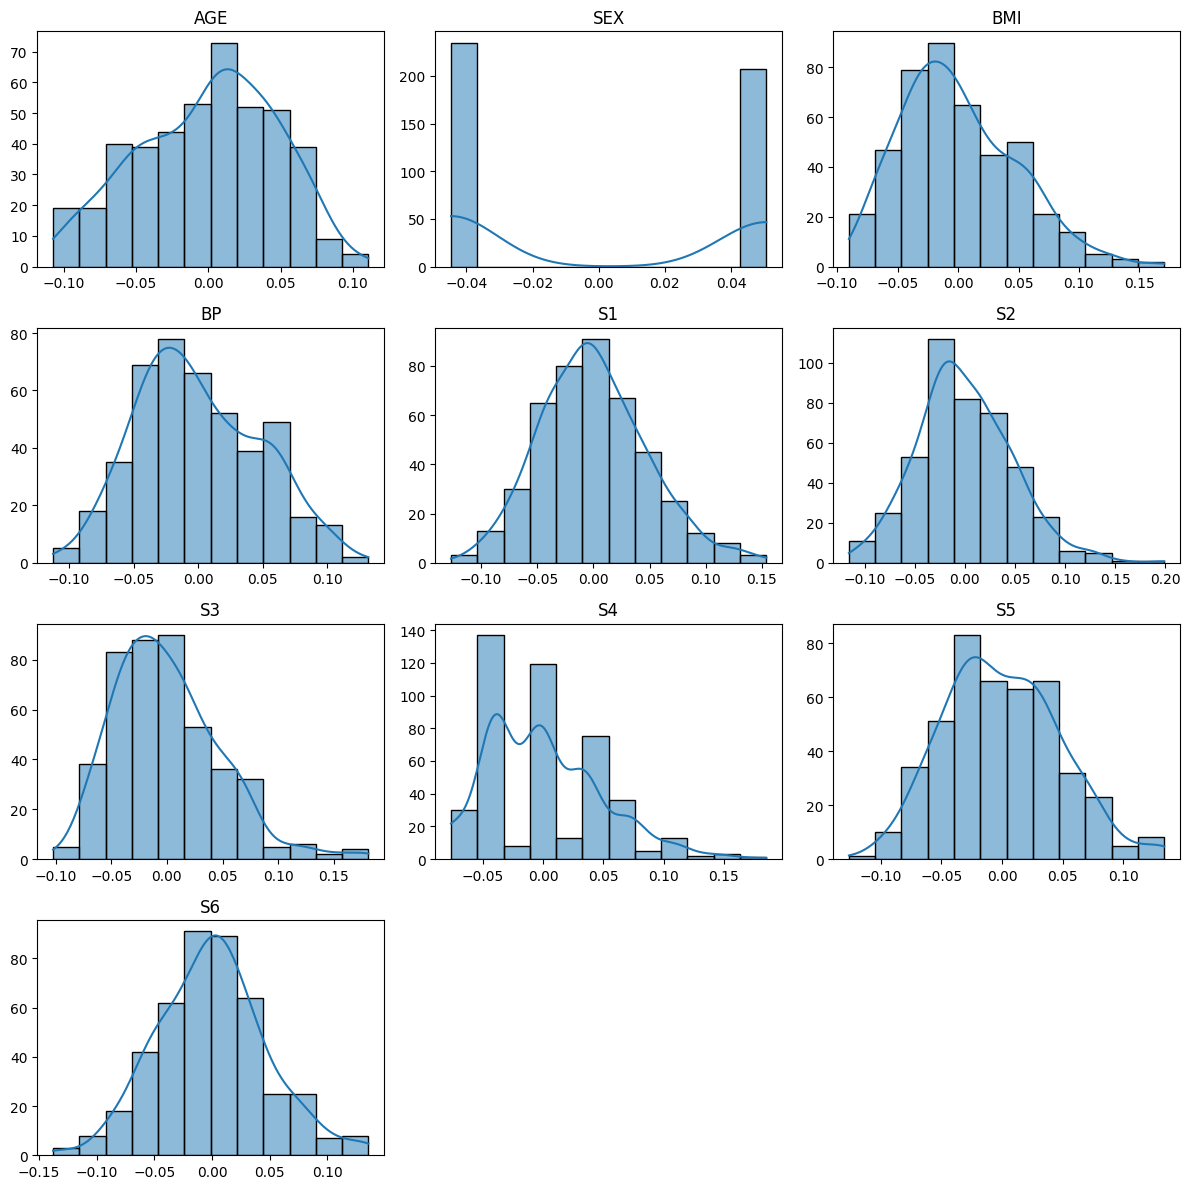

In [6]:
n = len(X.columns)
r = (n + 2)//3
fig, ax = plt.subplots(r, 3, figsize=(12, 3*r))
ax = ax.ravel()

for i, col in enumerate(X.columns):
    sns.histplot(X[col], bins=12, kde=True, edgecolor="k", ax=ax[i])
    ax[i].set_title(col.upper())
    ax[i].set_xlabel(""); ax[i].set_ylabel("")

for j in range(i+1, len(ax)):
    ax[j].axis("off")

plt.tight_layout(); plt.show()

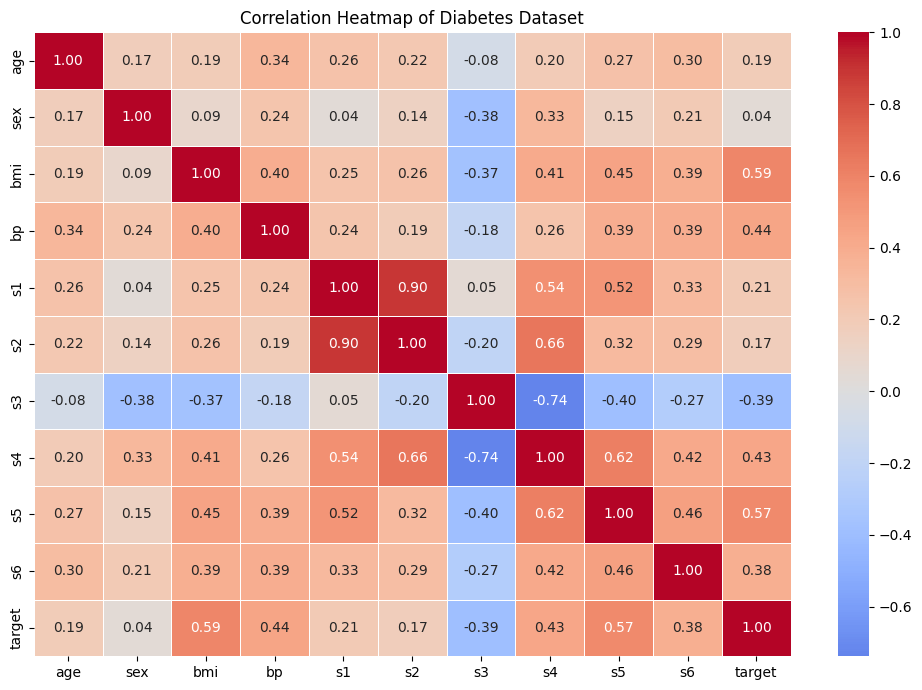

In [7]:
c = df.corr(numeric_only=True)
plt.figure(figsize=(10,7))
sns.heatmap(c, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            linewidths=.5, linecolor="white")
plt.title("Correlation Heatmap of Diabetes Dataset")
plt.tight_layout(); plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)


X_train: (353, 10) | X_test: (89, 10)


## Task 2: Linear Regression Model

In [9]:
lr = LinearRegression().fit(X_train, y_train)
print("Baseline test R2:", lr.score(X_test, y_test))


Baseline test R2: 0.4526027629719195


## Task 3: Implement Recursive Feature Elimination (RFE)

    k        r2
9   1  0.233350
8   2  0.452293
7   3  0.445095
6   4  0.446404
5   5  0.438201
4   6  0.462777
3   7  0.458255
2   8  0.455901
1   9  0.458659
0  10  0.452603

Coefficients (NaN=eliminated):
       age       sex       bmi        bp        s1        s2        s3  \
1      NaN       NaN  998.5777       NaN       NaN       NaN       NaN   
2      NaN       NaN  732.1090       NaN       NaN       NaN       NaN   
3      NaN       NaN  737.6856       NaN -228.3399       NaN       NaN   
4      NaN       NaN  691.4601       NaN -592.9779  362.9503       NaN   
5      NaN       NaN  597.8927  306.6479 -655.5606  409.6222       NaN   
6      NaN -215.2674  557.3142  350.1787 -851.5157  591.0933       NaN   
7      NaN -235.3642  551.8664  362.3561 -660.6432  343.3481       NaN   
8      NaN -233.7547  550.7444  363.7918 -947.8231  541.5858  172.2506   
9      NaN -236.6496  542.7995  354.2114 -936.3506  528.7966  167.8004   
10  37.904 -241.9644  542.4288  347.7038 -931.4888  

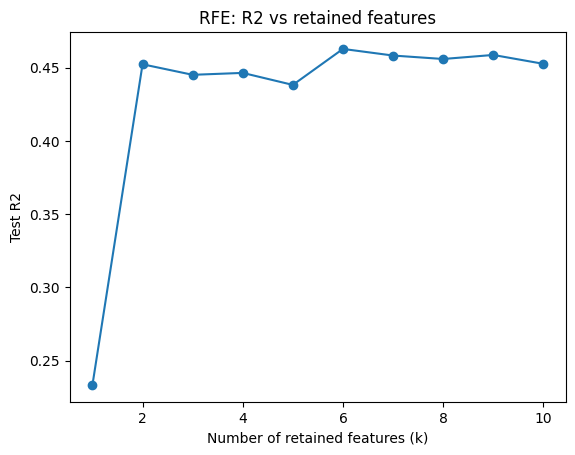

Optimal k (threshold = 0.01 ): 2
R2 at optimal k: 0.4522925957397932


In [10]:
p = X.shape[1]
ks, r2s, rows = [], [], []

for k in range(p, 0, -1):
    rfe = RFE(LinearRegression(), n_features_to_select=k, step=1).fit(X_train, y_train)
    ks.append(k)
    r2s.append(r2_score(y_test, rfe.predict(X_test)))

    coefs = np.full(p, np.nan)
    coefs[rfe.support_] = rfe.estimator_.coef_
    rows.append(coefs)

scores = pd.DataFrame({"k": ks, "r2": r2s}).sort_values("k")
coef_table = pd.DataFrame(rows, columns=X.columns, index=ks).sort_index()

print(scores)
print('\nCoefficients (NaN=eliminated):')
print(coef_table.round(4))

plt.plot(scores["k"], scores["r2"], marker="o")
plt.xlabel("Number of retained features (k)")
plt.ylabel("Test R2")
plt.title("RFE: R2 vs retained features")
plt.show()

thr = 0.01
s = scores.reset_index(drop=True)
opt_k = int(s["k"].iloc[-1])
for i in range(1, len(s)):
    if s["r2"].iloc[i] - s["r2"].iloc[i-1] < thr:
        opt_k = int(s["k"].iloc[i-1])
        break

print("Optimal k (threshold =", thr, "):", opt_k)
print("R2 at optimal k:", s.loc[s["k"]==opt_k, "r2"].iloc[0])


## Task 4: Analyze Feature Importance

In [11]:
init_rank_abs = pd.Series(lr.coef_, index=X.columns).abs().sort_values(ascending=False)
print("Initial ranking by coef:\n", init_rank_abs)
print("\nTop 3:", list(init_rank_abs.head(3).index))

rfe_opt = RFE(LinearRegression(), n_features_to_select=opt_k, step=1).fit(X_train, y_train)
selected = list(X.columns[rfe_opt.support_])

print("\nFinal selected features (k={}):".format(opt_k), selected)
print("Selected positions in initial ranking:",
      {f: int(init_rank_abs.index.get_loc(f))+1 for f in selected})

rfe_rank = RFE(LinearRegression(), n_features_to_select=1, step=1).fit(X_train, y_train)
print("\nRFE ranking (1=best):\n", pd.Series(rfe_rank.ranking_, index=X.columns).sort_values())


Initial ranking by coef:
 s1     931.488846
s5     736.198859
bmi    542.428759
s2     518.062277
bp     347.703844
s4     275.317902
sex    241.964362
s3     163.419983
s6      48.670657
age     37.904021
dtype: float64

Top 3: ['s1', 's5', 'bmi']

Final selected features (k=2): ['bmi', 's5']
Selected positions in initial ranking: {'bmi': 3, 's5': 2}

RFE ranking (1=best):
 bmi     1
s5      2
s1      3
s2      4
bp      5
sex     6
s4      7
s3      8
s6      9
age    10
dtype: int64


### - **Top 3 features:** s1, s5, bmi. These have the largest effect on the prediction in a linear model.

#**Task 5: Reflection**


1. What did you learn about feature selection using RFE?

RFE removes the least important feature one at a time and checks how the model performs each time. It showed me that you can use fewer features and still get good predictions.

2. How does RFE compare to other feature selection methods like LASSO in terms of methodology and results?

RFE keeps refitting the model and removes the weakest feature step by step. LASSO fits the model once and uses a penalty to shrink some coefficients to zero, which automatically removes features. RFE is easier to follow step by step, while LASSO is quicker but depends on picking the right penalty value.

3. What insights can you draw about the dataset from the selected features?

The features that remained at the end are the most important for predicting the outcome. This means they have the strongest relationship with the target, while the removed features don’t add much useful information for this linear model.